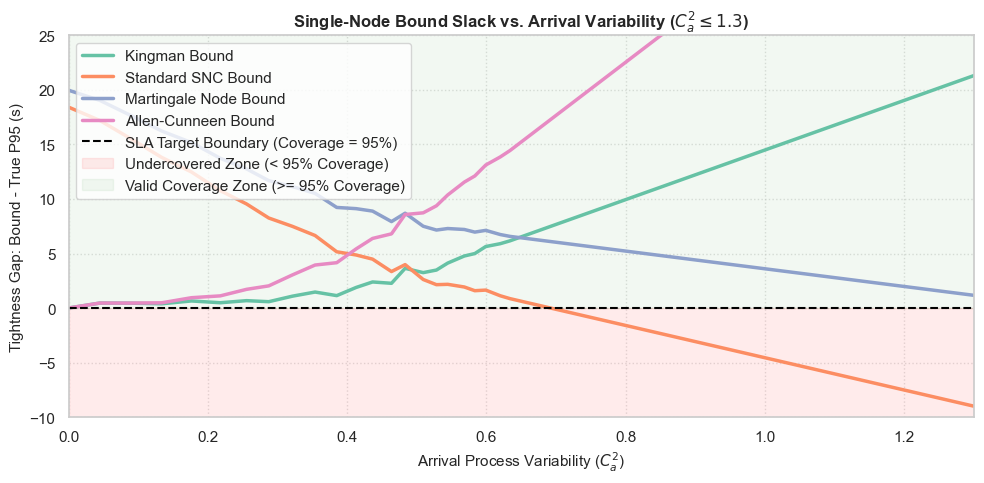

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)
sns.set_theme(style="whitegrid")

# ==============================================================================
# 1. QUEUE SIMULATION FUNCTION
# ==============================================================================
def simulate_queue(interarrivals, service_rate=1.0/4.8):
    num_customers = len(interarrivals)
    service_times = np.full(num_customers, 1.0 / service_rate) # Deterministic C_s^2 = 0

    arrival_times = np.cumsum(interarrivals)
    wait_times = np.zeros(num_customers)
    completion_times = np.zeros(num_customers)

    completion_times[0] = arrival_times[0] + service_times[0]
    wait_times[0] = 0.0

    for i in range(1, num_customers):
        wait_times[i] = max(0.0, completion_times[i-1] - arrival_times[i])
        completion_times[i] = arrival_times[i] + wait_times[i] + service_times[i]

    return wait_times

# Helper to generate interarrivals targeting a specific C_a^2
def generate_interarrivals_for_ca2(target_ca2, num_samples, mean_interarrival=6.0):
    if target_ca2 == 0:
        return np.full(num_samples, mean_interarrival)
    elif target_ca2 <= 1.0:
        sigma = np.sqrt(target_ca2) * mean_interarrival
        times = np.random.normal(mean_interarrival, sigma, num_samples)
        return np.maximum(0.001, times)
    else:
        p = 0.28
        ratio = target_ca2 / 1.5
        mean1 = mean_interarrival * (0.40 * ratio)
        mean2 = mean_interarrival * (1.0 + (0.65 * ratio))
        choices = np.random.rand(num_samples) < p
        return np.where(choices,
                        np.random.exponential(mean1, num_samples),
                        np.random.exponential(mean2, num_samples))

# ==============================================================================
# 2. RUN SIMULATION ACROSS INCREASING ARRIVAL VARIABILITY (C_a^2 <= 1.3)
# ==============================================================================
N = 100000
alpha = 0.05               # 95th Percentile Target
service_rate = 1.0 / 4.8   # mu = 1 / 4.8
service_time = 4.8         # E[S] = 4.8s
rho = 4.8 / 6.0            # Utilization = 0.80
c_s_sq = 0.0               # Deterministic service times

# X-axis grid: Cut x-axis at C_a^2 = 1.3
ca2_grid = np.linspace(0.0, 1.3, 30)

simulated_p95 = []
actual_ca2_list = []

for target_ca2 in ca2_grid:
    interarrivals = generate_interarrivals_for_ca2(target_ca2, N)
    waits = simulate_queue(interarrivals, service_rate=service_rate)

    emp_ca2 = np.var(interarrivals) / (np.mean(interarrivals) ** 2)
    p95 = np.percentile(waits, (1 - alpha) * 100)

    actual_ca2_list.append(emp_ca2)
    simulated_p95.append(p95)

actual_ca2_arr = np.array(actual_ca2_list)
simulated_p95_arr = np.array(simulated_p95)

# ==============================================================================
# 3. EVALUATE SINGLE-NODE BOUND METHODS
# ==============================================================================
bounds_dict = {}

# Method 1: Kingman Heavy-Traffic Bound (c = 1.0)
mean_wait_kingman = (rho / (1.0 - rho)) * ((actual_ca2_arr + c_s_sq) / 2.0) * service_time
bounds_dict["Kingman Bound"] = mean_wait_kingman * (1.0 + 1.0 * np.log(1.0 / alpha))

# Method 2: Standard Stochastic Network Calculus (SNC MGF Bound, theta = 0.25)
theta_snc = 0.25
effective_arrival_snc = 1.0 + (theta_snc * actual_ca2_arr)
bounds_dict["Standard SNC Bound"] = (1.0 / theta_snc) * np.log(effective_arrival_snc / (alpha * (1.0 - rho)))

# Method 3: Martingale Concentration Bound (theta = 0.15)
theta_mart = 0.15
bounds_dict["Martingale Node Bound"] = (1.0 / theta_mart) * np.log(1.0 / alpha) * (1.0 + theta_mart * actual_ca2_arr / (2.0 * (1.0 - rho)))

# Method 4: Allen-Cunneen Approximated Bound
mean_wait_ac = (rho / (1.0 - rho)) * ((actual_ca2_arr + c_s_sq) / 2.0) * service_time
ac_factor = np.exp(-2.0 * (1.0 - rho) / (rho * (actual_ca2_arr + c_s_sq + 1e-6)))
bounds_dict["Allen-Cunneen Bound"] = mean_wait_ac * (1.0 + np.log(1.0 / alpha) * (1.0 + ac_factor))

# Compute Tightness Gap: Bound - True P95
tightness_dict = {method: bounds_dict[method] - simulated_p95_arr for method in bounds_dict}

# ==============================================================================
# 4. VISUALIZATION (LINEAR Y-AXIS & CUT AT X = 1.3)
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(10, 5), dpi=100)
palette = sns.color_palette("Set2", len(tightness_dict))

for idx, (method, tightness) in enumerate(tightness_dict.items()):
    ax1.plot(actual_ca2_arr, tightness, label=method, color=palette[idx], linewidth=2.5)

# Zero line represents exact coverage threshold (Coverage = 95%)
ax1.axhline(0, color='black', linestyle='--', linewidth=1.5, label='SLA Target Boundary (Coverage = 95%)')

# Visual zones
ax1.axhspan(-15, 0, color='red', alpha=0.08, label='Undercovered Zone (< 95% Coverage)')
ax1.axhspan(0, 100, color='green', alpha=0.05, label='Valid Coverage Zone (>= 95% Coverage)')

ax1.set_xlabel("Arrival Process Variability ($C_a^2$)", fontsize=11)
ax1.set_ylabel("Tightness Gap: Bound - True P95 (s)", fontsize=11)
ax1.set_title("Single-Node Bound Slack vs. Arrival Variability ($C_a^2 \\leq 1.3$)", fontsize=12, fontweight='bold')
ax1.set_xlim(0.0, 1.3)
ax1.set_ylim(-10, 25)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()